In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../dataset/superstore.xlsx.csv', encoding='latin1')

# Show first 5 rows
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [5]:
# Dataset information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
# Missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


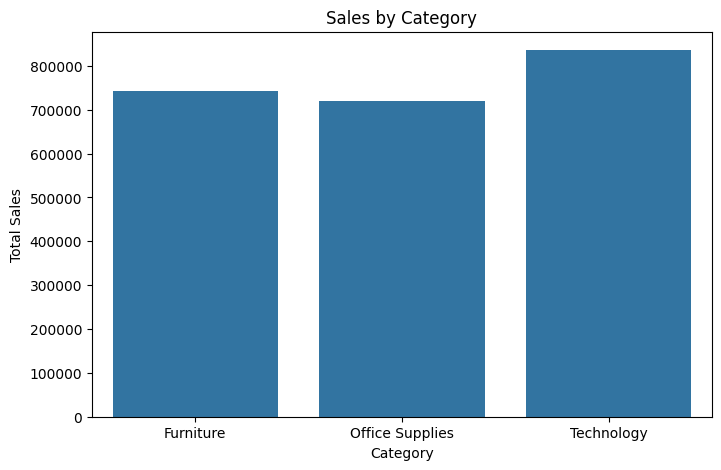

In [7]:
sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=sales_by_category.index,
    y=sales_by_category.values
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

Technology category generated the highest sales among all categories, indicating strong customer demand for technology products.

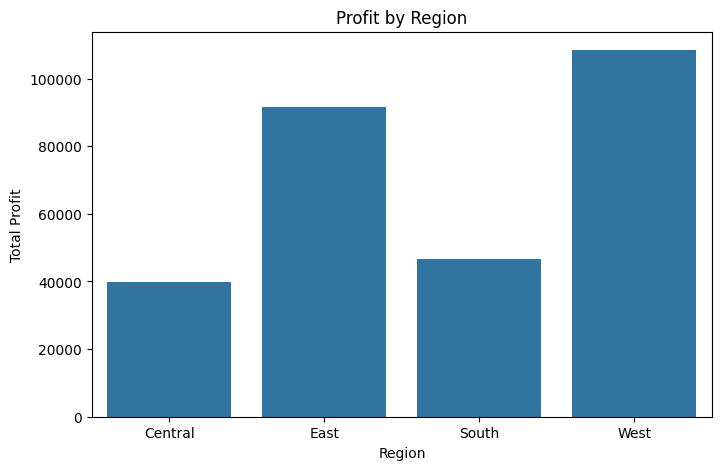

In [8]:
profit_by_region = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_by_region.index,
    y=profit_by_region.values
)

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')

plt.show()

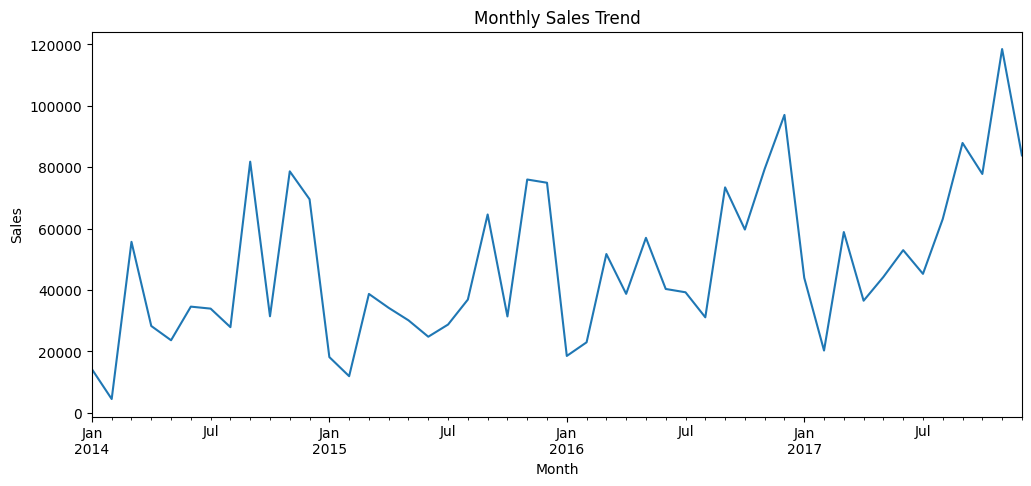

In [9]:
# Convert order date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract month-year
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

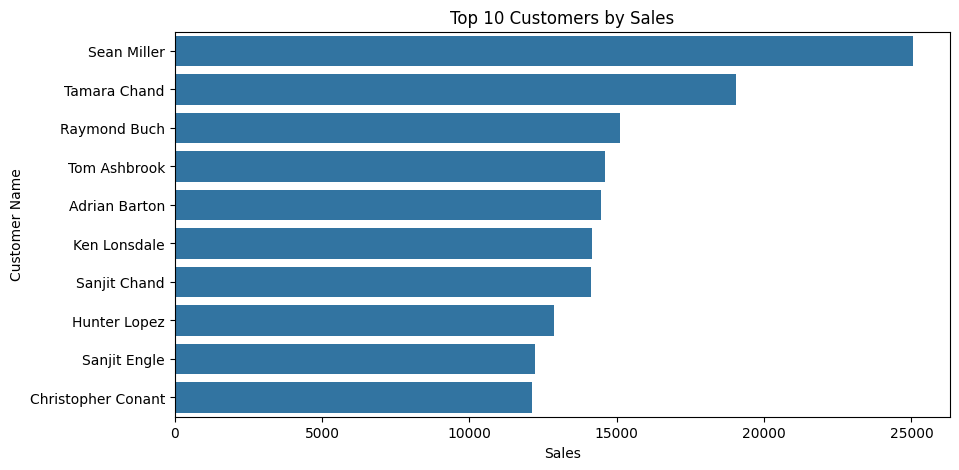

In [10]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer Name')

plt.show()

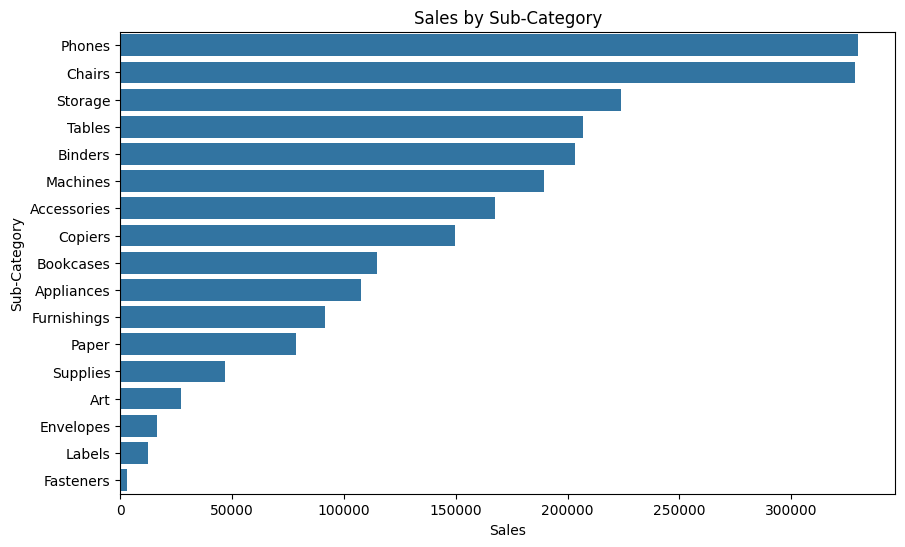

In [11]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')

plt.show()

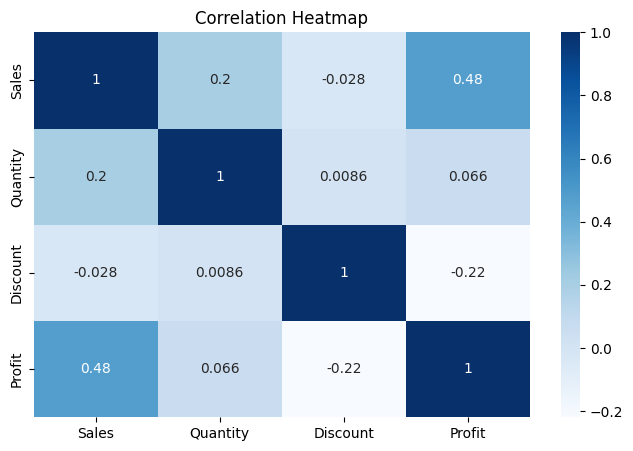

In [12]:
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')

plt.show()

In [13]:
df.to_csv('../dataset/clean_superstore.csv', index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
